#Chile - Universidad Adolfo Ibáñez (UAI)
##Curso NLP
### Text Classification - Sentiment Analysis (Inglés) - CNN & RNN

# Carga & Exploración de Datos

In [1]:
#Importar Librerías
import pandas as pd
import numpy as np
import spacy

In [2]:
#Importar Archivos
df_train = pd.read_csv('/content/sentiment_analysis_train.csv', encoding='latin-1')
df_test = pd.read_csv('/content/sentiment_analysis_test.csv', encoding='latin-1')

In [3]:
#Verificar Columnas
print("Columnas Train:", df_train.columns)
print("Columnas Test:", df_test.columns)

Columnas Train: Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')
Columnas Test: Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')


In [4]:
#Verificar Distribución Label (Train)
print("Label Distribution (Train)\n", df_train['Sentiment'].value_counts(normalize=True))

Label Distribution (Train)
 Sentiment
Positive    0.4330
Negative    0.3722
Neutral     0.1948
Name: proportion, dtype: float64


In [5]:
#Verificar Distribución Label (Test)
print("Label Distribution (Train)\n", df_test['Sentiment'].value_counts(normalize=True))

Label Distribution (Train)
 Sentiment
Negative    0.449
Positive    0.404
Neutral     0.147
Name: proportion, dtype: float64


# Embedding Matrix

In [6]:
#Importar Librerías
import tensorflow as tf
from tensorflow import keras
from keras.layers import TextVectorization

In [7]:
#Descargar spaCy pipeline
!python -m spacy download en_core_web_lg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 5.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [8]:
#Cargar Pipeline
nlp = spacy.load("en_core_web_lg")

In [9]:
#Crear Vocabulario
vectorizer = TextVectorization()
vectorizer.adapt(df_train['OriginalTweet'])
vocab = vectorizer.get_vocabulary()

In [10]:
#Generar Embedding Matrix
num_tokens = len(vocab)
embedding_dim = len(nlp('The').vector)
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for i, word in enumerate(vocab):
  embedding_matrix[i] = nlp(word.lower()).vector

print("Dimensionalidad Embedding Matrix:", embedding_matrix.shape)

Dimensionalidad Embedding Matrix: (19975, 300)


# Pre-Procesamiento

In [11]:
#Importar Librerías
#from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from sklearn.preprocessing import LabelBinarizer

In [12]:
#Crear & Ajustar Tokenizador (Keras)
vocab_size = num_tokens
oov_token = '<OOV>'
tokenizer = Tokenizer(num_words=vocab_size,
                      oov_token=oov_token)
tokenizer.fit_on_texts(df_train['OriginalTweet'])

In [13]:
#Crear Sequencias de Texto (Train)
trunc_type = 'post'
max_length = 250
X_train_seq = tokenizer.texts_to_sequences(df_train['OriginalTweet'])
X_train_seq_padded = pad_sequences(X_train_seq, padding=trunc_type, maxlen=max_length)
print("X Train Sequences:", X_train_seq_padded.shape)

X Train Sequences: (5000, 250)


In [14]:
#Crear Sequencias de Texto (Test)
X_test_seq = tokenizer.texts_to_sequences(df_test['OriginalTweet'])
X_test_seq_padded = pad_sequences(X_test_seq, padding=trunc_type, maxlen=max_length)
print("X Train Sequences:", X_test_seq_padded.shape)

X Train Sequences: (1000, 250)


In [15]:
#Listado Ordeneado de Clases
classes = ['Negative',
           'Neutral',
           'Positive']

In [16]:
#Crear & Entrenar Objeto LabelBinarizer
lb = LabelBinarizer()
lb.fit(df_train['Sentiment'])

LabelBinarizer()

In [17]:
#Creación Vector Labels
y_train = lb.transform(df_train['Sentiment'])
y_test = lb.transform(df_test['Sentiment'])

# CNN (5 Layers)

In [18]:
#Importar Librerías
from keras.models import Sequential
from keras.layers import Dense, Embedding,Conv1D,GlobalMaxPool1D
from keras import initializers
from keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score

In [19]:
#Creación & Configuración Objeto Sequential

#Inicializar Modelo
model_cnn_3l = Sequential()

#Capa Entrada - Embedding Layer
model_cnn_3l.add(Embedding(input_dim = vocab_size,
                           output_dim = embedding_dim,
                           embeddings_initializer=initializers.Constant(embedding_matrix),
                           trainable=False))

#Convolutional Layer
model_cnn_3l.add(Conv1D(32,5, activation='relu'))

#Max Pooling Layer
model_cnn_3l.add(GlobalMaxPool1D())

#Fully Connected Layer
model_cnn_3l.add(Dense(32, activation='relu'))

#Capa Salida
model_cnn_3l.add(Dense(3, activation = 'softmax'))

#Compilación
model_cnn_3l.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_cnn_3l.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
#Configurar EarlyStopping
early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=3)

In [21]:
#Entrenar CNN
history_cnn_3l = model_cnn_3l.fit(X_train_seq_padded, y_train,
                                  batch_size=5,
                                  epochs=10,
                                  validation_split = 0.2,
                                  callbacks=[early_stop])

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4190 - loss: 1.0430 - val_accuracy: 0.4440 - val_loss: 0.9845
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5164 - loss: 0.9635 - val_accuracy: 0.5000 - val_loss: 0.9709
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6777 - loss: 0.7585 - val_accuracy: 0.5440 - val_loss: 0.9503
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8247 - loss: 0.4867 - val_accuracy: 0.5500 - val_loss: 1.0998
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9214 - loss: 0.2474 - val_accuracy: 0.5480 - val_loss: 1.3971
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9579 - loss: 0.1316 - val_accuracy: 0.5390 - val_loss: 1.6289
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9831 - loss: 0.0667 - val_accuracy: 0.5480 - val_loss: 1.9455


In [22]:
#Gráfico Accuracy & Loss (Training & Validation)

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

def plot_accuracy_loss(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training Accuracy')
    plt.plot(x, val_acc, 'r', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Number of Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training Loss')
    plt.plot(x, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Number of Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

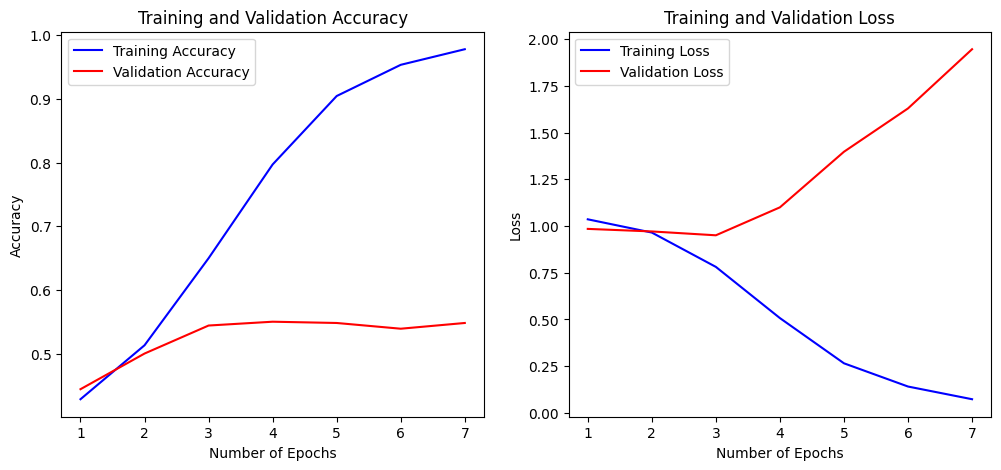

In [23]:
#Revisar Accuracy & Loss
plot_accuracy_loss(history_cnn_3l)

In [24]:
#Umbral de Predicción
threshold = 0.5

In [25]:
#Evaluar ANN
y_pred_cnn_3l = model_cnn_3l.predict(X_test_seq_padded) > threshold
print('F1 Score (Weighted)', round(f1_score(y_test, y_pred_cnn_3l, average='weighted'),3))
print('F1 Score (por Clase)', f1_score(y_test, y_pred_cnn_3l, average=None))

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
F1 Score (Weighted) 0.485
F1 Score (por Clase) [0.53170189 0.25777778 0.51575263]


# RNN (4 Layers)

In [26]:
#Importar Librerías
from keras.layers import Bidirectional, LSTM

In [27]:
#Creación & Configuración Objeto Sequential

#Inicializar Modelo
model_rnn_3l = Sequential()

#Capa Entrada - Embedding Layer
model_rnn_3l.add(Embedding(input_dim = vocab_size,
                           output_dim = embedding_dim,
                           embeddings_initializer=initializers.Constant(embedding_matrix),
                           trainable=False))

#LSTM Layer
model_rnn_3l.add(Bidirectional(LSTM(units=10)))

#Fully Connected Layer
model_rnn_3l.add(Dense(10, activation='relu'))

#Capa Salida
model_rnn_3l.add(Dense(3, activation = 'softmax'))

#Compilación
model_rnn_3l.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_rnn_3l.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
#Entrenar RNN
history_rnn_3l = model_rnn_3l.fit(X_train_seq_padded, y_train,
                                  batch_size=5,
                                  epochs=5,
                                  validation_split = 0.2,
                                  callbacks=[early_stop])

Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.4263 - loss: 1.0527 - val_accuracy: 0.4750 - val_loss: 0.9830
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.4915 - loss: 0.9879 - val_accuracy: 0.4990 - val_loss: 0.9493
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.5635 - loss: 0.9211 - val_accuracy: 0.5200 - val_loss: 0.9319
Epoch 4/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.6200 - loss: 0.8413 - val_accuracy: 0.5340 - val_loss: 0.9411
Epoch 5/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.6800 - loss: 0.7541 - val_accuracy: 0.5860 - val_loss: 0.9070


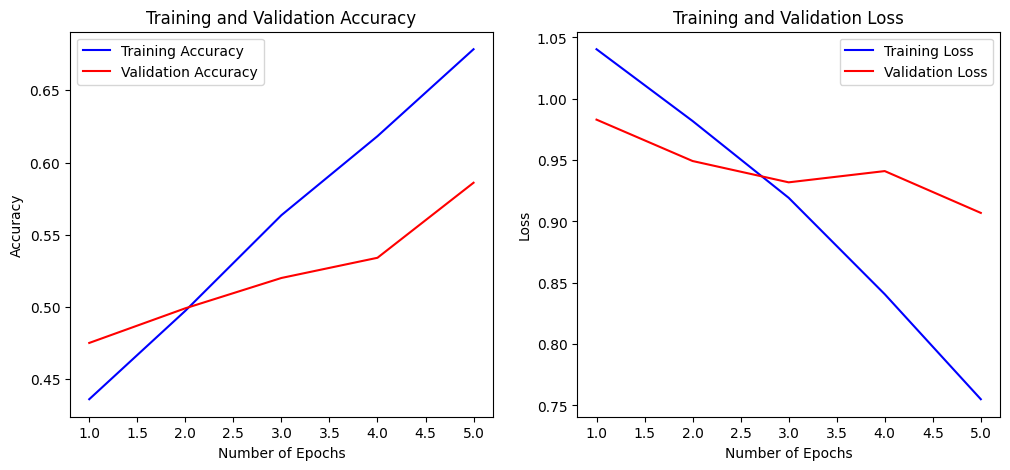

In [29]:
#Revisar Accuracy & Loss
plot_accuracy_loss(history_rnn_3l)

In [30]:
#Evaluar RNN
y_pred_rnn_3l = model_rnn_3l.predict(X_test_seq_padded) > threshold
print('F1 Score (Weighted)', round(f1_score(y_test, y_pred_rnn_3l, average='weighted'),3))
print('F1 Score (por Clase)', f1_score(y_test, y_pred_rnn_3l, average=None))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
F1 Score (Weighted) 0.47
F1 Score (por Clase) [0.4068323  0.31531532 0.59742829]
